In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
import spatialdata as sd

In [6]:
import scanpy as sc
import anndata as ad
from scipy import io
from scipy.sparse import coo_matrix, csr_matrix
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import squidpy as sq
import seaborn as sns
from shapely.geometry import Point, Polygon
from pathlib import Path
from typing import Dict, List, Tuple
import matplotlib.patches as patches

In [10]:
from scipy.spatial.distance import cdist
from scipy import stats

In [8]:
adata = sc.read_h5ad('annotated_data.h5ad') #import annotated data

In [ ]:
# ==============================================================================
# 1. SETUP & POPULATION DEFINITIONS
# ==============================================================================
# Ensure spatial coordinates exist
if 'spatial' not in adata.obsm:
    adata.obsm['spatial'] = adata.obs[['x_spatial', 'y_spatial']].values
# Identifying Cell Populations (Your logic preserved here)
adata.obs['is_tcell'] = adata.obs['celltype'] == 'T cells'
adata.obs['is_epi'] = adata.obs['celltype'] == 'Epithelial'
adata.obs['is_stem'] = adata.obs['epi_subtype'] == 'SC'
# Crypt = Stem + Transit-Amplifying + Paneth
crypt_types = ['SC', 'TA', 'Paneth']
adata.obs['is_crypt'] = adata.obs['epi_subtype'].isin(crypt_types)

In [ ]:
# ==============================================================================
# 2. CALCULATION
# ==============================================================================

def calculate_tcell_interactions(adata_subset, max_distance=50):
    t_cells = adata_subset[adata_subset.obs['is_tcell']].copy()
    if len(t_cells) == 0: return None
    
    t_coords = t_cells.obsm['spatial']
    results = {'n_tcells': len(t_cells)}
    
    # Process each population mask
    masks = {
        'epi': adata_subset[adata_subset.obs['is_epi']].copy(),
        'stem': adata_subset[adata_subset.obs['is_stem']].copy(),
        'crypt': adata_subset[adata_subset.obs['is_crypt']].copy()
    }
    
    for label, cells in masks.items():
        if len(cells) > 0:
            distances = cdist(t_coords, cells.obsm['spatial'], metric='euclidean')
            nearest = distances.min(axis=1)
            results[f'median_distance_{label}'] = np.median(nearest)
            results[f'pct_tcells_near_{label}'] = (nearest <= max_distance).mean() * 100
            results[f'mean_tcells_per_{label}'] = (distances <= max_distance).sum(axis=0).mean()
            
    return results

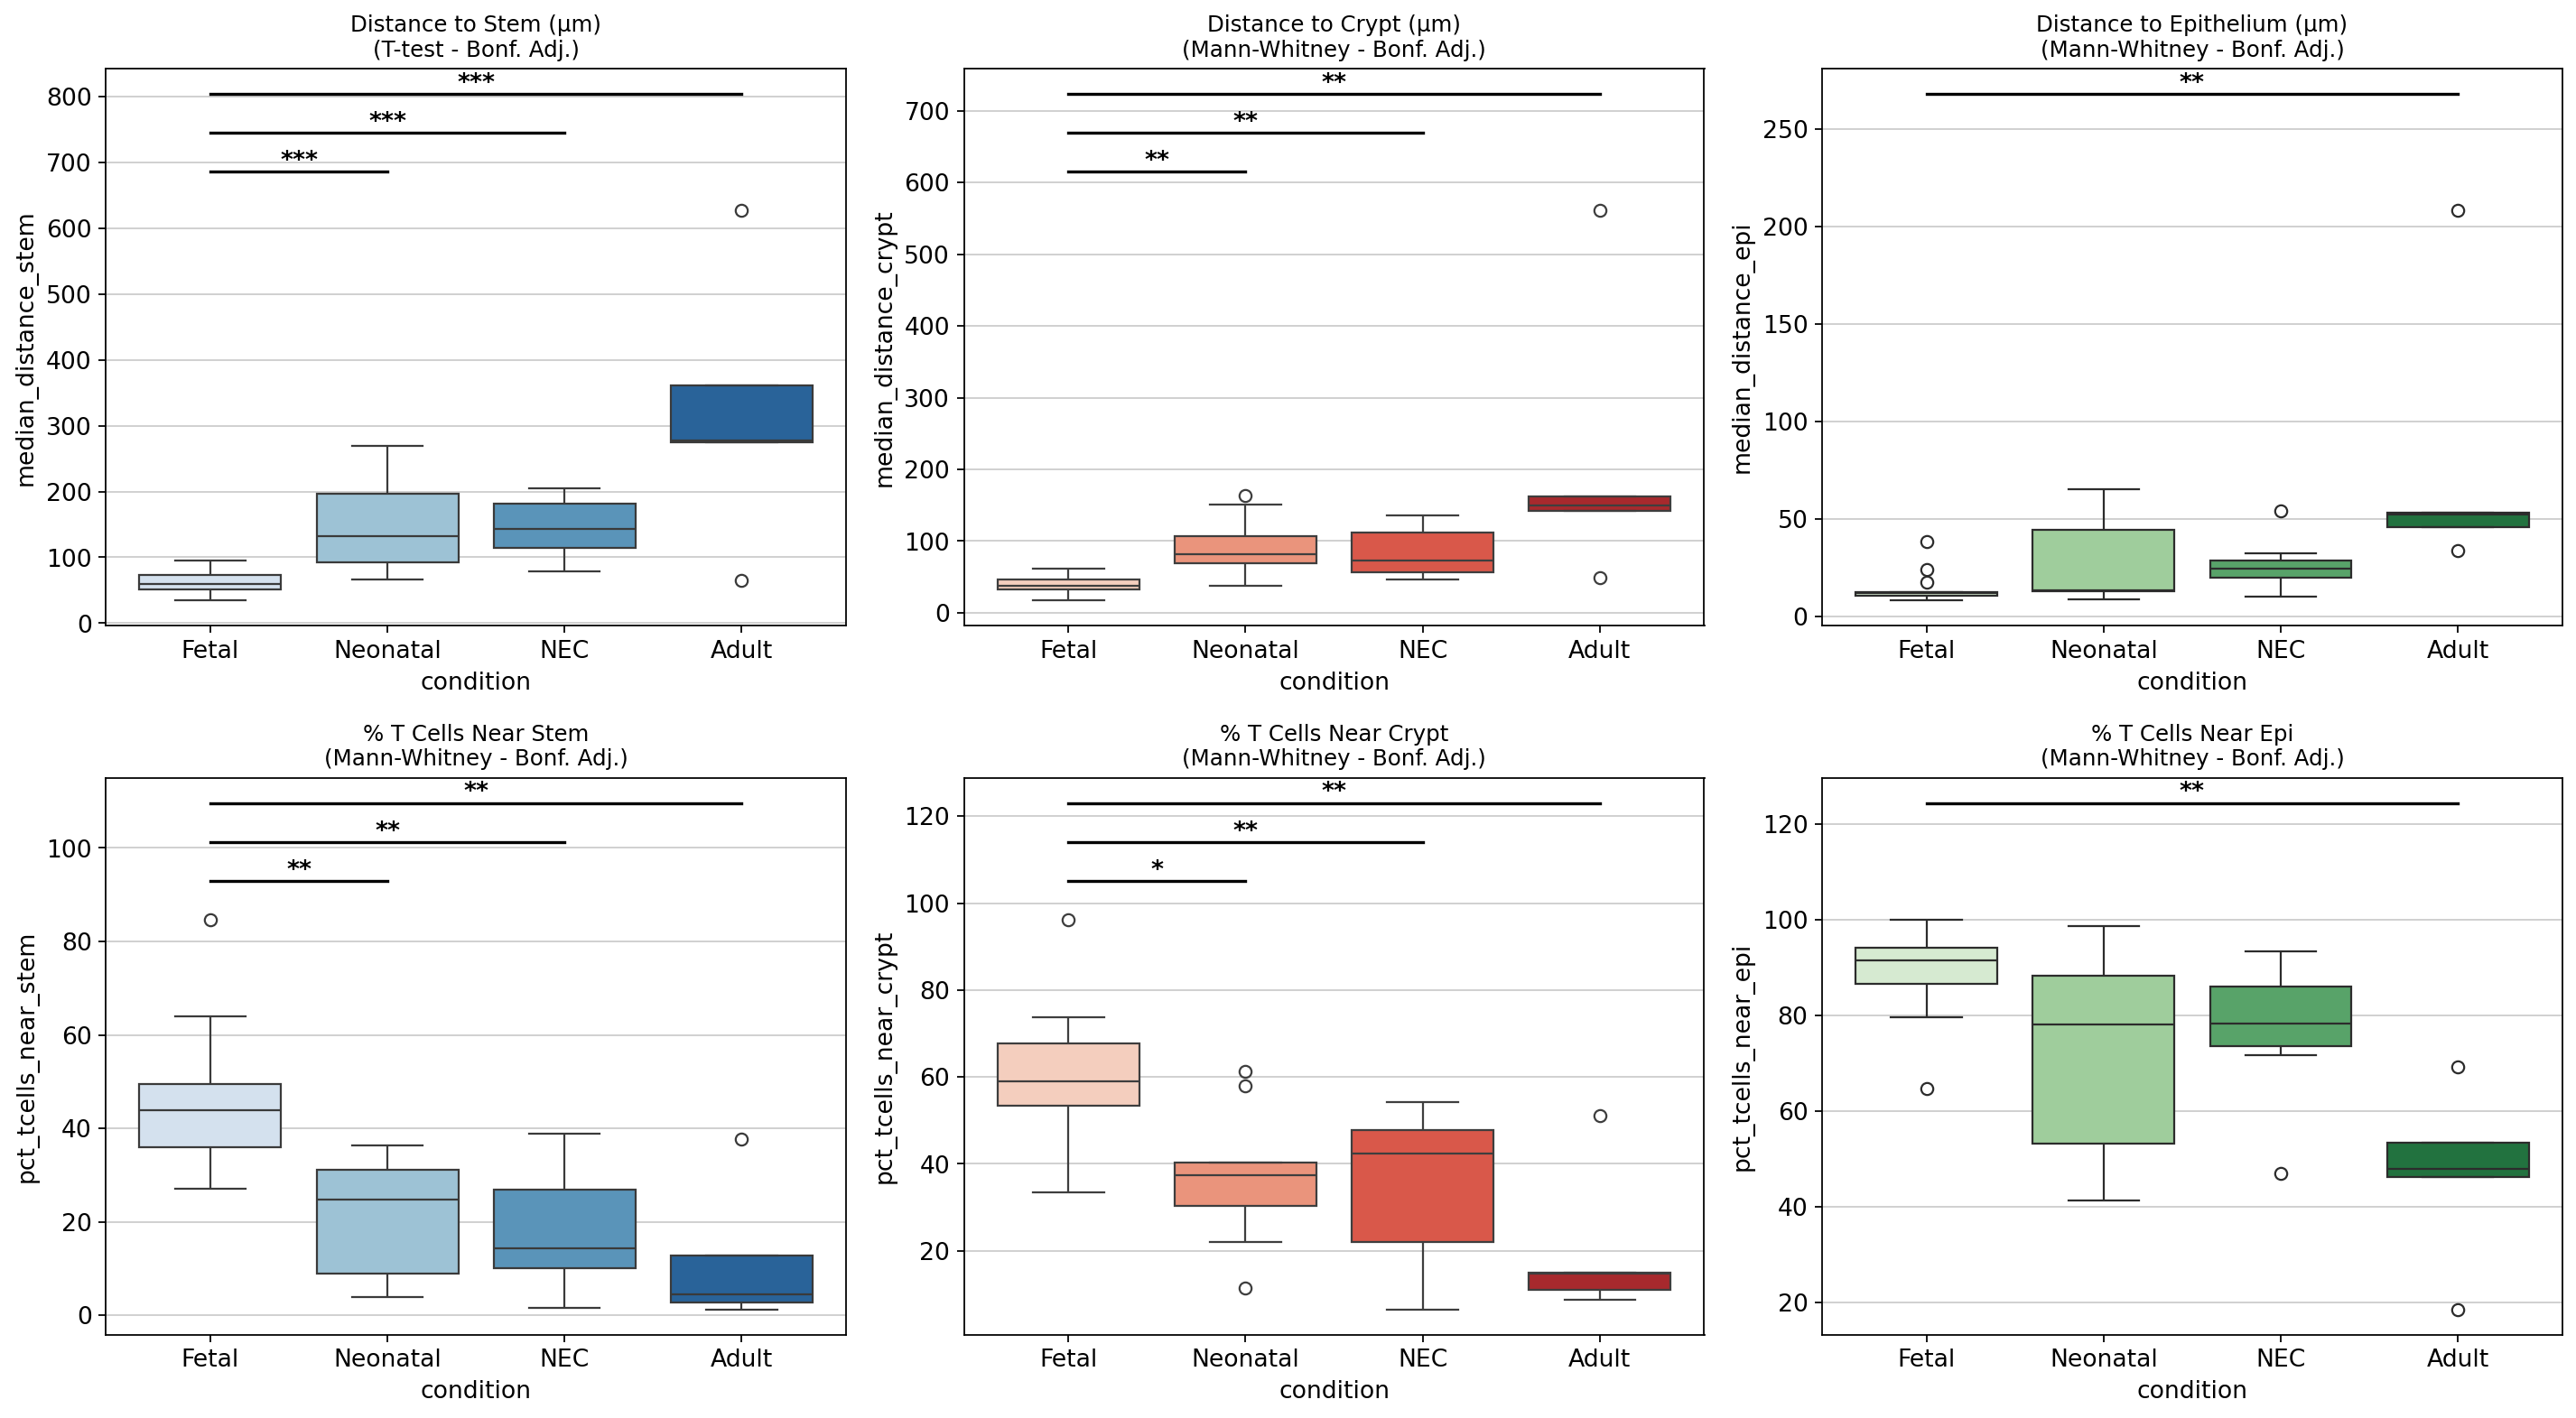

In [24]:


# ==============================================================================
# 3. STATISTICAL ENGINE (Consistent Global Approach)
# ==============================================================================

def perform_consistent_analysis(df, metric, conditions, reference='Fetal'):
    """
    Performs one normality check for the entire metric. 
    If normal, uses T-test for all; if not, uses Mann-Whitney for all.
    """
    # 1. Gather all groups for this metric
    groups = {c: df[df['condition'] == c][metric].dropna() for c in conditions}
    valid_groups = [g for g in groups.values() if len(g) >= 3]
    
    if len(valid_groups) < 2:
        return {c: 1.0 for c in conditions if c != reference}, "Insufficient Data"

    # 2. Global Normality Check (Conservative: if any group fails, use non-parametric)
    shapiro_ps = [stats.shapiro(g)[1] for g in valid_groups]
    is_normal = all([p > 0.05 for p in shapiro_ps])
    
    # 3. Choose consistent test
    pair_test = stats.ttest_ind if is_normal else stats.mannwhitneyu
    test_name = "T-test" if is_normal else "Mann-Whitney"
    
    # 4. Run consistent comparisons
    results = {}
    conditions_to_test = [c for c in conditions if c != reference]
    n_tests = len(conditions_to_test)
    ref_data = groups[reference]
    
    for cond in conditions_to_test:
        comp_data = groups[cond]
        _, p_raw = pair_test(ref_data, comp_data)
        
        # Bonferroni Correction
        results[cond] = min(p_raw * n_tests, 1.0)
        
    return results, test_name

# ==============================================================================
# 4. EXECUTION & PLOTTING
# ==============================================================================

# Extract Data
interaction_results = []
for tissue_id in adata.obs['tissue_id'].unique():
    subset = adata[adata.obs['tissue_id'] == tissue_id].copy()
    res = calculate_tcell_interactions(subset)
    if res:
        res.update({'tissue_id': tissue_id, 'condition': subset.obs['condition'].iloc[0]})
        interaction_results.append(res)

df_interactions = pd.DataFrame(interaction_results)
conditions_present = [c for c in ['Fetal', 'Neonatal', 'NEC', 'Adult'] if c in df_interactions['condition'].unique()]

# Plotting Loop
metrics_to_plot = [
    ('median_distance_stem', 'Distance to Stem (µm)', 'Blues'),
    ('median_distance_crypt', 'Distance to Crypt (µm)', 'Reds'),
    ('median_distance_epi', 'Distance to Epithelium (µm)', 'Greens'),
    ('pct_tcells_near_stem', '% T Cells Near Stem', 'Blues'),
    ('pct_tcells_near_crypt', '% T Cells Near Crypt', 'Reds'),
    ('pct_tcells_near_epi', '% T Cells Near Epi', 'Greens')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (metric, ylabel, palette) in enumerate(metrics_to_plot):
    ax = axes[i]
    sns.boxplot(data=df_interactions, x='condition', y=metric, ax=ax, palette=palette, order=conditions_present)
    
    # Run Stats
    p_dict, test_name = perform_consistent_analysis(df_interactions, metric, conditions_present)
    
    # Annotate plot
    ax.set_title(f"{ylabel}\n({test_name} - Bonf. Adj.)", fontsize=11)
    
    # Add brackets
    y_max = df_interactions[metric].max()
    y_range = df_interactions[metric].max() - df_interactions[metric].min()
    
    for idx, (cond, pval) in enumerate(p_dict.items()):
        # We skip Fetal because that is the reference
        if cond == 'Fetal': continue
        
        y_bracket = y_max + (y_range * 0.1 * (idx + 1))
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        
        if sig != 'ns':
            ax.plot([0, conditions_present.index(cond)], [y_bracket, y_bracket], color='black', lw=1.5)
            ax.text(conditions_present.index(cond)/2, y_bracket + (y_range * 0.01), sig, ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("/gpfs/gibbs/pi/konnikova/Leo2/maddi_paper/fig_tcell_allsubset_distance.pdf", bbox_inches="tight")
plt.show()